In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..") / "src"))

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from load import load_subject
from preprocess import prepare_run

DATA_DIRECTORY = Path("..") / "data" / "Subjects"
RESULT_DIRECTORY = Path("..") / "results"
RESULT_DIRECTORY.mkdir(parents = True, exist_ok = True)

np.random.seed(69)
torch.manual_seed(42)

In [2]:
run4_path = DATA_DIRECTORY / "S001R04.edf"
run8_path = DATA_DIRECTORY / "S001R08.edf"

raw_run4, events_run4, raw_run8, events_run8 = load_subject(run4_path, run8_path)

print("Run 4 loaded:", len(raw_run4.ch_names), "electrode channels,", events_run4.shape[0], "events found")
print("Run 8 loaded:", len(raw_run8.ch_names), "electrode channels,", events_run8.shape[0], "events found")

Used Annotations descriptions: ['T0', 'T1', 'T2']


Used Annotations descriptions: ['T0', 'T1', 'T2']


Run 4 loaded: 64 electrode channels, 30 events found
Run 8 loaded: 64 electrode channels, 30 events found


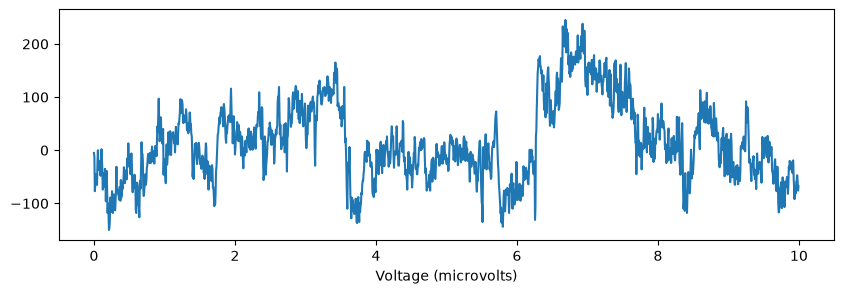

In [3]:
sfreq = raw_run4.info["sfreq"]
first_channel = raw_run4.ch_names[0]
signal, times = raw_run4[first_channel, : int(sfreq * 10)]

plt.figure(figsize = (10, 3))
plt.plot(times, signal[0] * 1000000)
plt.xlabel("Time (seconds)")
plt.xlabel("Voltage (microvolts)")
plt.show()

In [4]:
X4, y4 = prepare_run(raw_run4, events_run4)
X8, y8 = prepare_run(raw_run8, events_run8)

print("Run 4 ->", X4.shape[0], "examples")
print("Run 8 ->", X8.shape[0], "examples")

Run 4 -> 15 examples
Run 8 -> 15 examples


In [5]:
X = np.concatenate([X4, X8], axis = 0)
y = np.concatenate([y4, y8], axis = 0)

n_examples, n_channels, n_timepoints = X.shape
print(f"Total: {n_examples} examples, {n_channels} EEG channels, {n_timepoints} timepoints each")
print(f"Left-hand examples: {(y == 0).sum()}  |  Right-hand examples: {(y == 1).sum()}")

Total: 30 examples, 64 EEG channels, 641 timepoints each
Left-hand examples: 16  |  Right-hand examples: 14


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 69, stratify= y)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

Training examples: 24
Testing examples: 6


In [7]:
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

BATCH_SIZE = 8

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size = BATCH_SIZE, shuffle = False)

In [8]:
class SimpleEEGNet(nn.Module):
    """A small 1D Convolutional Neural Network (CNN) for left/right classification."""

    def __init__(self, n_channels):
        super().__init__()

        # First convolution: looks for simple patterns across a short time window
        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=16, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(16)   # keeps the numbers flowing through the network stable
        self.pool1 = nn.MaxPool1d(2)    # shrinks the signal by half, keeping the strongest values

        # Second convolution: builds more complex patterns from the first layer's output
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)  # squashes whatever length is left to a single value per feature
        self.output_layer = nn.Linear(32, 2)        # turns 32 features into 2 scores: one for "left", one for "right"

        self.relu = nn.ReLU()           # adds non-linearity so the network can learn complex patterns
        self.dropout = nn.Dropout(0.5)  # randomly ignores some neurons while training, to avoid overfitting

    def forward(self, x):
        # x starts as: (batch_size, n_channels, n_timepoints)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = self.global_pool(x)   # shape becomes (batch_size, 32, 1)
        x = x.squeeze(-1)         # drop the last dimension -> (batch_size, 32)
        x = self.dropout(x)

        return self.output_layer(x)  # shape: (batch_size, 2) -> one score per class


model = SimpleEEGNet(n_channels=n_channels)
print(model)

SimpleEEGNet(
  (conv1): Conv1d(64, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [9]:
loss_function = nn.CrossEntropyLoss()  # the standard loss for "pick one of several categories" problems
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam is a popular, reliable choice of optimizer

N_EPOCHS = 30  # one "epoch" = one full pass through all the training data

In [10]:
train_losses = []  # we'll store the loss after each epoch so we can plot it later

for epoch in range(1, N_EPOCHS + 1):
    model.train()  # tell the model we're training (affects dropout/batch-norm behavior)
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()           # clear leftover gradients from the previous batch
        predictions = model(batch_X)    # forward pass: run this batch through the network
        loss = loss_function(predictions, batch_y)  # how wrong were we?
        loss.backward()                 # backward pass: work out how to adjust each weight
        optimizer.step()                # actually update the weights

        total_loss += loss.item() * batch_X.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch}/{N_EPOCHS} — training loss: {avg_loss:.4f}")

print("Training done!")

Epoch 1/30 — training loss: 0.7063
Epoch 5/30 — training loss: 0.6557
Epoch 10/30 — training loss: 0.6431


Epoch 15/30 — training loss: 0.5064
Epoch 20/30 — training loss: 0.4876
Epoch 25/30 — training loss: 0.4140
Epoch 30/30 — training loss: 0.3242
Training done!


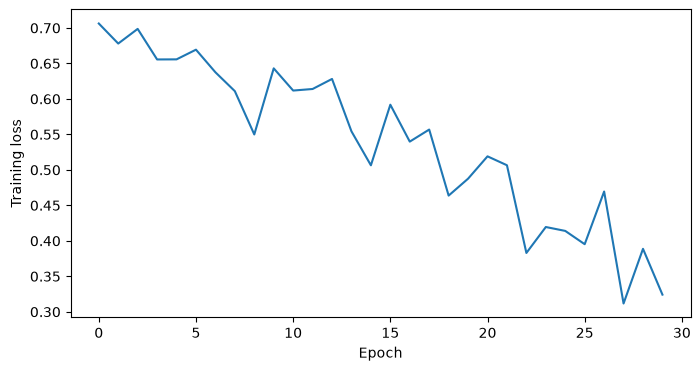

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.savefig(RESULT_DIRECTORY / "accuracy.png")  # save the plot so it can be reviewed later
plt.show()

In [12]:
model.eval()  # tell the model we're testing, not training

with torch.no_grad():  # we don't need to track gradients when just testing
    predictions = model(X_test_t)
    predicted_labels = predictions.argmax(dim=1)  # pick the class with the higher score

correct = (predicted_labels == y_test_t).sum().item()
total = y_test_t.size(0)
print(f"Test accuracy: {correct / total:.1%} ({correct}/{total} correct)")

# A simple breakdown of correct vs. total for each class
for label, name in [(0, "Left"), (1, "Right")]:
    mask = (y_test_t == label)
    class_total = mask.sum().item()
    class_correct = (predicted_labels[mask] == label).sum().item()
    print(f"  {name}: {class_correct}/{class_total} correct")

Test accuracy: 50.0% (3/6 correct)
  Left: 3/3 correct
  Right: 0/3 correct


In [13]:
# state_dict() holds just the model's learned numbers (weights). Saving it
# lets us reload this exact trained model later without retraining.
weights_path = RESULT_DIRECTORY / "eeg_cnn_weights.pt"
torch.save(model.state_dict(), weights_path)
print("Saved trained model to:", weights_path)

Saved trained model to: ..\results\eeg_cnn_weights.pt


In [14]:
COMMANDS = {0: "MOVE_LEFT_ARM", 1: "MOVE_RIGHT_ARM"}  # map each predicted class to a robot arm command

model.eval()
with torch.no_grad():
    for i in range(5):  # just look at the first 5 test examples
        one_example = X_test_t[i].unsqueeze(0)  # add a "batch" dimension of size 1
        prediction = model(one_example).argmax(dim=1).item()

        command = COMMANDS[prediction]
        actual = "Left" if y_test[i] == 0 else "Right"
        print(f"Example {i}: model predicted '{command}'  (actual: {actual})")

Example 0: model predicted 'MOVE_LEFT_ARM'  (actual: Right)
Example 1: model predicted 'MOVE_LEFT_ARM'  (actual: Right)
Example 2: model predicted 'MOVE_LEFT_ARM'  (actual: Left)
Example 3: model predicted 'MOVE_LEFT_ARM'  (actual: Left)
Example 4: model predicted 'MOVE_LEFT_ARM'  (actual: Right)
